
--- S41_A01_T02.raw ---
  qsLLL: 29 peaks, 29 troughs


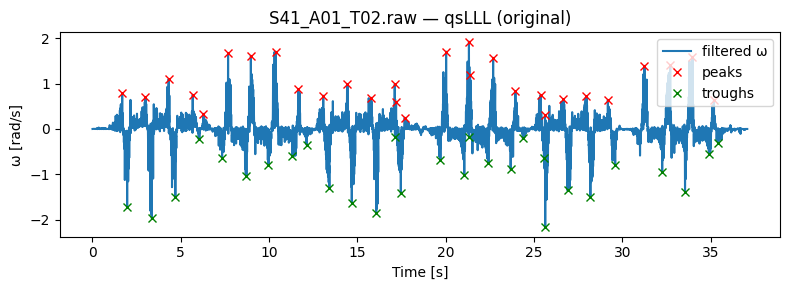

  qsLLL after correction: 31 peaks, 27 troughs


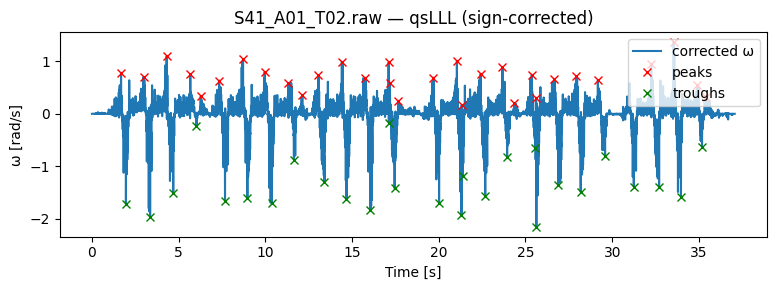

  qsRLL: 31 peaks, 31 troughs


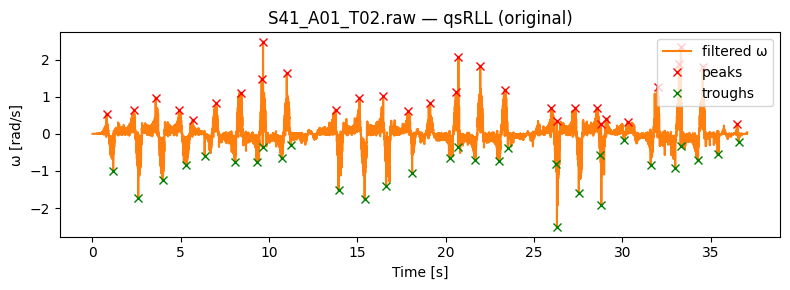

  qsRLL after correction: 33 peaks, 29 troughs


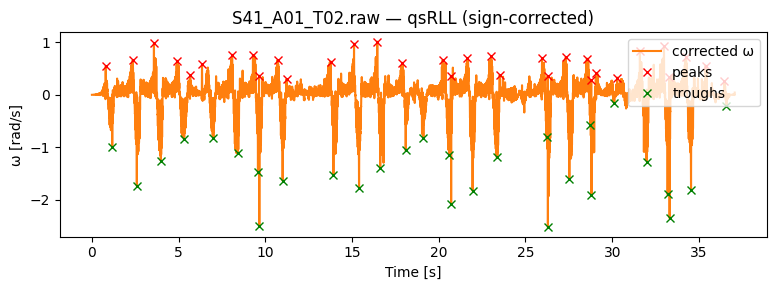

In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt, hilbert

# --- Configuration ----------------------------------------------------------
root_dir = '/Users/mario/Documents/TFG_VIDIMU/vidiMU/benchmark/jointangles/jointangles_imus'
sensors  = ['qsLLL', 'qsRLL']
colors   = {'qsLLL': 'tab:blue', 'qsRLL': 'tab:orange'}
fs       = 50                  # IMU sample-rate  [Hz]
dt       = 1.0 / fs            # time step        [s]
cutoff   = 6.0                 # LP-cut-off       [Hz]
min_dist = 0.5                 # min event gap    [s]

# --- Basic helpers (unchanged) ----------------------------------------------
def butter_lowpass(cut, fs, order=4):
    b, a = butter(order, cut / (0.5*fs), btype='low', analog=False)
    return b, a

def lowpass_filter(x, cut, fs, order=4):
    b, a = butter_lowpass(cut, fs, order)
    return filtfilt(b, a, x)

def detect_gait_events(ω, fs, cut=6.0, min_d=0.5):
    ωf = lowpass_filter(ω, cut, fs)
    μ, σ = ωf.mean(), ωf.std()
    dist = int(min_d*fs)
    p,_ = find_peaks( ωf, distance=dist, prominence=0.5*σ, height=μ+0.5*σ)
    t,_ = find_peaks(-ωf, distance=dist, prominence=0.5*σ, height=-(μ-0.5*σ))

    idx = np.sort(np.r_[p, t])
    typ = ['peak' if i in p else 'trough' for i in idx]

    # enforce alternation -----------------------------------------------------
    keep_idx, keep_typ = [], []
    for i, ty in zip(idx, typ):
        if keep_typ and keep_typ[-1] == ty:       # duplicate type → keep stronger
            last = keep_idx[-1]
            if ty == 'peak' and ωf[i] > ωf[last]:
                keep_idx[-1] = i
            elif ty == 'trough' and ωf[i] < ωf[last]:
                keep_idx[-1] = i
        else:
            keep_idx.append(i); keep_typ.append(ty)

    peaks   = [i for i,t in zip(keep_idx, keep_typ) if t=='peak']
    troughs = [i for i,t in zip(keep_idx, keep_typ) if t=='trough']
    return ωf, peaks, troughs                    # NOTE: count = len(peaks)+len(troughs)

# --- Quaternion helpers (unchanged) -----------------------------------------
def quat_conjugate(q):
    qc = q.copy();  qc[...,1:] *= -1;  return qc

def quat_multiply(a, b):
    w1,x1,y1,z1 = a.T
    w2,x2,y2,z2 = b.T
    return np.column_stack([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])

# ----------------------------------------------------------------------------
def process_file(file_path):
    df = pd.read_csv(file_path, header=0)
    df.rename(columns={df.columns[0]:'sensor'}, inplace=True)
    for c in ['w','x','y','z','timestamp']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df.dropna(subset=['w','x','y','z','timestamp'], inplace=True)
    df = df[df['timestamp'] != 0.0]

    print(f"\n--- {os.path.basename(file_path)} ---")
    for sensor in sensors:
        grp = df[df['sensor']==sensor].sort_values('timestamp').reset_index(drop=True)
        if len(grp) < 2:
            print(f"  {sensor}: not enough data, skipping"); continue

        # ----- quaternion → angular-velocity ---------------------------------
        q  = grp[['w','x','y','z']].values.copy()
        ts = grp['timestamp'].values
        t  = ts - ts[0]

        # enforce quaternion continuity
        dots = np.sum(q[1:]*q[:-1], axis=1)
        q[1:][dots < 0] *= -1

        dq   = quat_multiply(q[1:], quat_conjugate(q[:-1]))
        w0   = np.clip(dq[:,0], -1.0, 1.0)
        ang  = 2*np.arccos(w0)
        sinh = np.sqrt(1 - w0*w0)
        axis = np.zeros_like(dq[:,1:])
        good = sinh > 1e-8
        axis[good] = dq[good,1:] / sinh[good,None]
        ω3d  = axis * (ang/dt)[:,None]
        t_w  = t[1:]

        # principal component
        comp = np.argmax(np.std(ω3d, axis=0))
        ω    = ω3d[:, comp]

        # ----- event detection on original signal ---------------------------
        ωf, peaks, troughs = detect_gait_events(ω, fs, cutoff, min_dist)
        print(f"  {sensor}: {len(peaks)} peaks, {len(troughs)} troughs")

        plt.figure(figsize=(8,3))
        plt.plot(t_w, ωf, color=colors[sensor], label='filtered ω')
        plt.plot(t_w[peaks],   ωf[peaks],   'xr', label='peaks')
        plt.plot(t_w[troughs], ωf[troughs], 'xg', label='troughs')
        plt.title(f'{os.path.basename(file_path)} — {sensor} (original)')
        plt.xlabel('Time [s]'); plt.ylabel('ω [rad/s]')
        plt.legend(loc='upper right'); plt.tight_layout(); plt.show()

        # =======  robust direction correction  ==============================
        # 1) locate turning (low-energy) periods via envelope -----------------
        env   = np.abs(hilbert(ωf))
        env_s = pd.Series(env).rolling(int(0.4*fs), center=True, min_periods=1).mean().values
        flat  = env_s < np.percentile(env_s, 15)
        segs  = []
        i = 0
        while i < len(flat):
            if not flat[i]:
                s = i
                while i < len(flat) and not flat[i]:
                    i += 1
                segs.append((s,i))
            else:
                i += 1
        if not segs: segs = [(0,len(ωf))]

        # 2) vote the dominant sign inside every walking segment -------------
        ωcorr  = ωf.copy()
        mag_thr = 0.15*np.std(ωf)
        for s,e in segs:
            pos = np.sum(ωf[s:e] >  mag_thr)
            neg = np.sum(ωf[s:e] < -mag_thr)
            if neg > pos:
                ωcorr[s:e] *= -1

        # 3) re-classify **all** original events by sign of ωcorr -------------
        all_evt = sorted(peaks + troughs)
        peaks_c   = [i for i in all_evt if ωcorr[i] > 0]
        troughs_c = [i for i in all_evt if ωcorr[i] < 0]
        print(f"  {sensor} after correction: {len(peaks_c)} peaks, {len(troughs_c)} troughs")

        # ----- plot corrected signal ----------------------------------------
        plt.figure(figsize=(8,3))
        plt.plot(t_w, ωcorr, color=colors[sensor], label='corrected ω')
        plt.plot(t_w[peaks_c],   ωcorr[peaks_c],   'xr', label='peaks')
        plt.plot(t_w[troughs_c], ωcorr[troughs_c], 'xg', label='troughs')
        plt.title(f'{os.path.basename(file_path)} — {sensor} (sign-corrected)')
        plt.xlabel('Time [s]'); plt.ylabel('ω [rad/s]')
        plt.legend(loc='upper right'); plt.tight_layout(); plt.show()

# ----------------------------------------------------------------------------
# --- Batch process A01 files (kept commented) ------------------------------
# for subj in sorted(os.listdir(root_dir)):
#     subj_dir = os.path.join(root_dir, subj)
#     if not os.path.isdir(subj_dir):
#         continue
#     print(f"\n=== Subject {subj} ===")
#     for fname in sorted(os.listdir(subj_dir)):
#         if '_A01_' in fname and fname.endswith('.raw'):
#             process_file(os.path.join(subj_dir, fname))

process_file(os.path.join(root_dir, 'S41', 'S41_A01_T02.raw'))
